Connectome shape: (33, 33)
Min: 0.0
Max: 0.6211567893017695
Mean: 0.23739080328710144


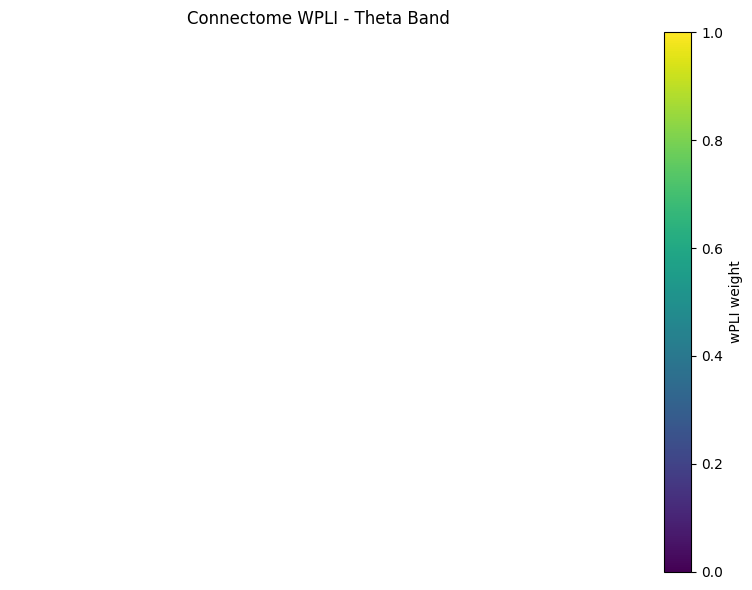

In [21]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import mne

# 1. Charger un connectome
subject_id = "sub-19684666"
freq_band = "theta"
method = "wpli"
filepath = f"../data/TDBRAIN/connectome/{subject_id}/ses-1/ses-1_{method}_{freq_band}.npy"
connectome = np.load(filepath)

print(f"Connectome shape: {connectome.shape}")
print("Min:", connectome.min())
print("Max:", connectome.max())
print("Mean:", connectome.mean())

# 2. Charger la position des électrodes (standard_1020)
montage = mne.channels.make_standard_montage('standard_1020')
ch_names = montage.ch_names[:connectome.shape[0]]
ch_pos = montage.get_positions()['ch_pos']
pos = {ch: ch_pos[ch][:2] for ch in ch_names if ch in ch_pos}

# 3. Créer le graphe
G = nx.Graph()
for i, ch1 in enumerate(ch_names):
    for j, ch2 in enumerate(ch_names):
        threshold = 0.01  # seuil 
        if j > i and connectome[i, j] > threshold:  
            G.add_edge(ch1, ch2, weight=connectome[i, j])

# 4. Tracer
fig, ax = plt.subplots(figsize=(8, 6))
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

# Dessiner avec edge_color et edge_cmap
nx.draw_networkx(
    G, pos, with_labels=True, node_size=300, font_size=10,
    edge_color=weights, edge_cmap=plt.cm.viridis, width=2, ax=ax
)

# Associer un mappable à la colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis)
sm.set_array(weights)
fig.colorbar(sm, ax=ax, label="wPLI weight")

ax.set_title(f"Connectome {method.upper()} - {freq_band.capitalize()} Band")
ax.axis('off')
plt.tight_layout()
plt.show()
